In [1]:
# Load the libraries 
import requests
from bs4 import BeautifulSoup
import networkx as nx
import matplotlib.pyplot as plt

In [2]:

# Add a user-agent so Wikipedia treats this like a normal browser request
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

# Start with the Major Depressive Disorder page as my seed page
url = "https://en.wikipedia.org/wiki/Major_depressive_disorder"

# Request the page with headers
response = requests.get(url, headers=headers)

# Check if the request was successful 
print(f"Status Code: {response.status_code}")

# Step 4: Parse the HTML: so I can search for links inside it
soup = BeautifulSoup(response.text, "html.parser")

# Create a list to store the links I find
links = []

# Loop through every anchor tag on the page and only keep internal Wikipedia article links
for link in soup.find_all("a"):
    href = link.get("href")
    if href and href.startswith("/wiki/") and ":" not in href:
        links.append(href)

# Show the first 20 links found
print(links[:20])

Status Code: 200
['/wiki/Main_Page', '/wiki/Main_Page', '/wiki/Major_depressive_disorder', '/wiki/Major_depressive_disorder', '/wiki/Major_depressive_disorder', '/wiki/Mood_disorder', '/wiki/Depression_(mood)', '/wiki/At_Eternity%27s_Gate', '/wiki/Vincent_van_Gogh', '/wiki/Medical_specialty', '/wiki/Psychiatry', '/wiki/Clinical_psychology', '/wiki/Signs_and_symptoms', '/wiki/Depression_(mood)', '/wiki/Self-esteem', '/wiki/Anhedonia', '/wiki/Psychomotor_retardation', '/wiki/Pain', '/wiki/Insomnia', '/wiki/Hypersomnia']


In [3]:
# clean up the links: remove "/wiki/" from the beginning and remove duplicates using set()
clean_links = list(set([link.replace("/wiki/", "") for link in links]))

print(clean_links[:20])
print("Total links:", len(clean_links))

['Amphetamine', 'Hallucinogen_persisting_perception_disorder', 'Temporal_lobe#Structure', 'Borderline_personality_disorder', 'National_Institute_of_Mental_Health', 'Depression_(differential_diagnoses)', 'Stereotypic_movement_disorder', 'Internet_addiction_disorder', 'Johann_Wolfgang_von_Goethe', 'Digital_zombie', 'Healthcare_in_the_Netherlands', 'Digital_detox', 'Lamotrigine', 'Somatization', 'Biopsychosocial_model', 'Calcium', 'Swedish_Agency_for_Health_Technology_Assessment_and_Assessment_of_Social_Services', 'Genetic_epidemiology', 'International_Statistical_Classification_of_Diseases_and_Related_Health_Problems', 'Vincent_van_Gogh']
Total links: 660


In [4]:
# This is the list of mental health pages I decided to focus on
mental_health_pages = [
"Major_depressive_disorder",
"Suicide",
"Substance_abuse",
"Addiction",
"Bipolar_disorder",
"Anxiety_disorder",
"Post-traumatic_stress_disorder",
"Borderline_personality_disorder",
"Dementia",
"Alzheimer%27s_disease",
"Traumatic_brain_injury",
"Chronic_traumatic_encephalopathy",
"Korsakoff_syndrome"
]

In [5]:
# Create a directed graph
G = nx.DiGraph()

In [6]:
# Loop through each mental health page in my selected list
for page in mental_health_pages:
    #build the full Wikipedia URL
    url = "https://en.wikipedia.org/wiki/" + page

    # Request the page and parse it
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")

    # Store links found on this page
    links = []

    # Go through every link on the page
    for link in soup.find_all("a"):
        href = link.get("href")
        if href and href.startswith("/wiki/") and ":" not in href:
            links.append(href.replace("/wiki/", ""))

    #remove dupliates
    clean_links = list(set(links))

    # This only create edges if the link points to another page in my selected list
    for target in clean_links:
        if target in mental_health_pages:
            G.add_edge(page, target)

In [7]:
# PRint nodes and edges in the graph
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 13
Edges: 97


In [8]:
# Count how many pages link to each page and show from highest to lowest

in_degree = dict(G.in_degree())
sorted(in_degree.items(), key=lambda x: x[1], reverse=True)

[('Post-traumatic_stress_disorder', 11),
 ('Substance_abuse', 11),
 ('Major_depressive_disorder', 10),
 ('Anxiety_disorder', 10),
 ('Bipolar_disorder', 10),
 ('Dementia', 9),
 ('Alzheimer%27s_disease', 9),
 ('Suicide', 8),
 ('Traumatic_brain_injury', 7),
 ('Borderline_personality_disorder', 4),
 ('Chronic_traumatic_encephalopathy', 4),
 ('Korsakoff_syndrome', 2),
 ('Addiction', 2)]

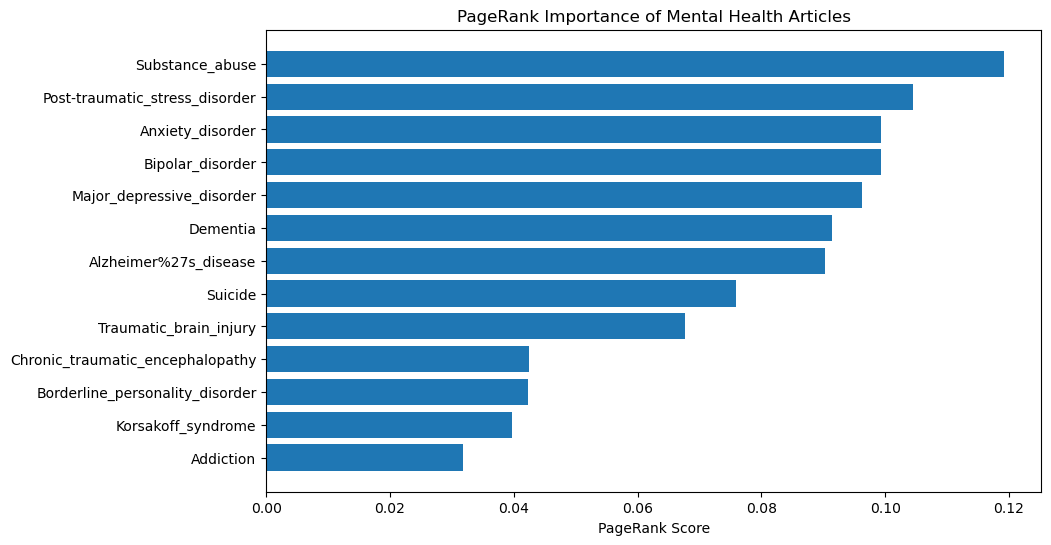

In [9]:
# Calculate Pagerank and show which pages are most important
pagerank = nx.pagerank(G)
sorted(pagerank.items(), key=lambda x: x[1], reverse=True)
top_pr = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)

names = [x[0] for x in top_pr]
values = [x[1] for x in top_pr]

plt.figure(figsize=(10,6))
plt.barh(names[::-1], values[::-1])
plt.title("PageRank Importance of Mental Health Articles")
plt.xlabel("PageRank Score")
plt.show()

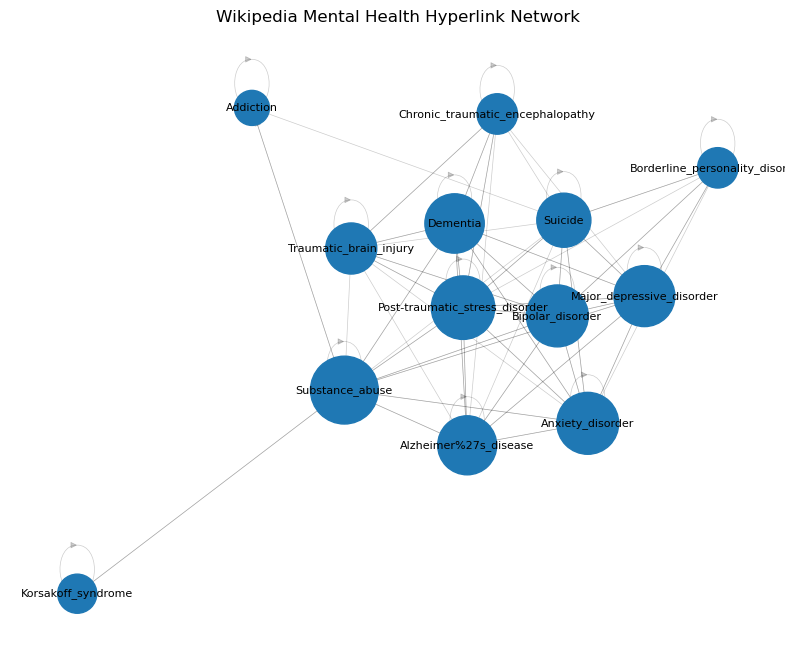

In [10]:
#mental health network graph (node size = PageRank)

plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G, seed=42)

node_sizes = [pagerank[node] * 20000 for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes)

nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.5)

nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("Wikipedia Mental Health Hyperlink Network")
plt.axis("off")
plt.show()

In [11]:
# Calclate betweenness centrality to see which pages act as bridges
bet = nx.betweenness_centrality(G)
sorted(bet.items(), key=lambda x: x[1], reverse=True)

[('Substance_abuse', 0.2763347763347763),
 ('Post-traumatic_stress_disorder', 0.0709054834054834),
 ('Suicide', 0.06464646464646465),
 ('Bipolar_disorder', 0.05701659451659452),
 ('Major_depressive_disorder', 0.04577922077922078),
 ('Dementia', 0.03775252525252525),
 ('Anxiety_disorder', 0.019895382395382397),
 ('Traumatic_brain_injury', 0.018127705627705624),
 ('Alzheimer%27s_disease', 0.014213564213564215),
 ('Chronic_traumatic_encephalopathy', 0.0059343434343434335),
 ('Addiction', 0.0030303030303030307),
 ('Borderline_personality_disorder', 0.0),
 ('Korsakoff_syndrome', 0.0)]